In [1]:
# importing libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet',
                 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

In [2]:
# loading csv file.
df = pd.read_csv("amazon_review.csv")
df.head()

,Review,Sentiment
0,Fast shipping but this product is very cheaply...,1
1,This case takes so long to ship and it's not e...,1
2,Good for not droids. Not good for iPhones. You...,1
3,The cable was not compatible between my macboo...,1
4,The case is nice but did not have a glow light...,1


In [3]:
# dataset contains 25000 entries.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     24999 non-null  object
 1   Sentiment  25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None


In [4]:
# checking for null values.
print("Missing:\n", df.isna().sum())
# checking for duplicate values.
print("Duplicates:", df.duplicated().sum())

Missing:
 Review       1
Sentiment    0
dtype: int64
Duplicates: 188


In [5]:
# removing null values.

df = df.dropna().drop_duplicates().reset_index(drop=True)
print("Shape of the data after cleaning : ", df.shape)

Shape of the data after cleaning :  (24811, 2)


In [6]:
# looking at the number of values of each unique item in the Sentiment column.

df['Sentiment'].value_counts()

,count
Sentiment,
2,4990
1,4984
3,4966
4,4960
5,4911


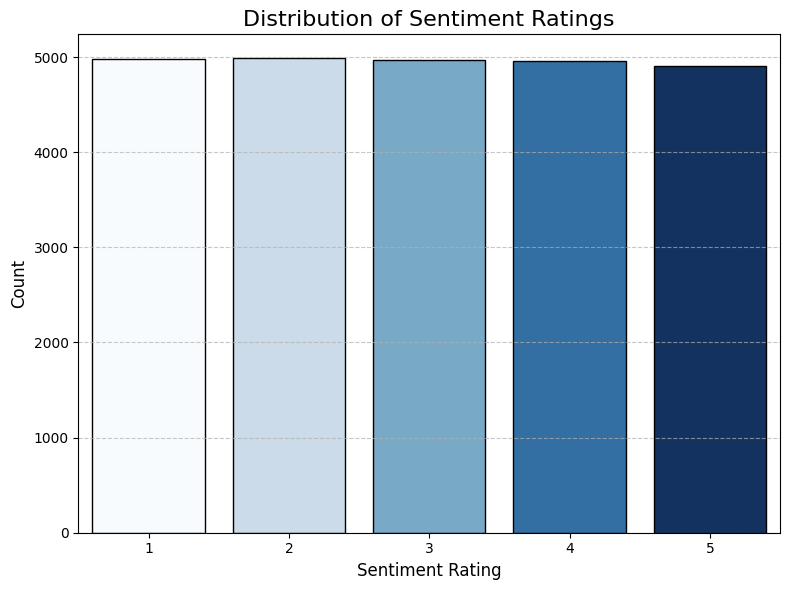

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='Blues', hue='Sentiment', legend=False, edgecolor='black')
plt.title('Distribution of Sentiment Ratings', fontsize=16)
plt.xlabel('Sentiment Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Text Cleaning

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
negations = {'not','no','nor',"isn't","wasn't","aren't","doesn't","didn't",
             "don't","won't","couldn't","shouldn't","wouldn't","hasn't",
             "haven't","hadn't"}
stop_words = set(stopwords.words('english')) - negations

In [9]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Map Penn Treebank POS tags to WordNet POS tags."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def clean_reviews(text):
    text = re.sub(r'<.*?>', ' ', text)           # 1. strip HTML tags
    text = re.sub(r'&#\d+;|&\w+;', ' ', text)    # 2. HTML entities like &#34;
    text = text.lower()                           # 3. lowercase
    text = re.sub(r"[^a-z\s']", ' ', text)       # 4. keep letters + apostrophes
    tokens = word_tokenize(text)                  # 5. split into words
    tokens = [w for w in tokens                   # 6. drop stopwords, 1-letter junk
              if w not in stop_words and len(w) > 1]
    tagged = pos_tag(tokens)                      # 7. tag each word's part of speech
    tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(t))
              for w, t in tagged]                 # 8. lemmatize using the POS
    return ' '.join(tokens)                       # 9. back to a single string

df['clean'] = df['Review'].apply(clean_reviews)
df = df[df['clean'].str.strip() != ''].reset_index(drop=True)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['Sentiment'],
    test_size=0.2, random_state=42, stratify=df['Sentiment'])

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)   # learn vocab + IDF from TRAIN only
X_test_vec  = tfidf.transform(X_test)        # apply same mapping to test

Logistic Regression 0.4798387096774194
Multinomial Naive Bayes 0.47318548387096776


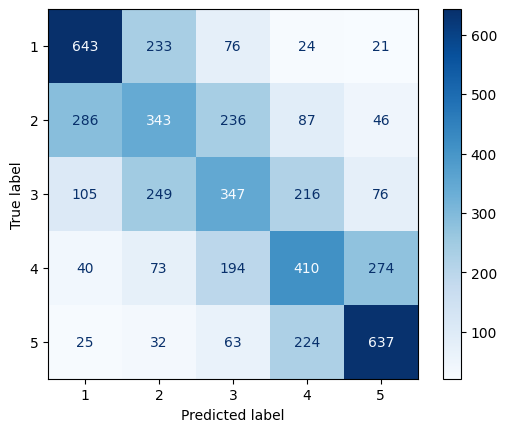

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    print(name, accuracy_score(y_test, model.predict(X_test_vec)))

cm = confusion_matrix(y_test, models['Logistic Regression'].predict(X_test_vec))
ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4,5]).plot(cmap='Blues')
plt.show()

Both models got about 48% right. Sounds bad, but with five star ratings, random guessing only gets 20%. And when we look at the mistakes, the model is almost always off by just one star, like guessing 4 when the answer was 5. Honestly, even people can't tell a 4-star review from a 5-star one. That's why sentiment analysis usually just asks "positive or negative?" instead. As for the models: Logistic Regression learns which words push a review toward each rating, and Naive Bayes just counts words for each class.


In [13]:
from sklearn.metrics import classification_report

df_bin = df[df['Sentiment'] != 3].copy()               # drop neutral reviews
df_bin['label'] = (df_bin['Sentiment'] >= 4).astype(int)  # 1-2 -> 0, 4-5 -> 1

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df_bin['clean'], df_bin['label'],
    test_size=0.2, random_state=42, stratify=df_bin['label'])

tfidf_bin = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
Xb_train_vec = tfidf_bin.fit_transform(Xb_train)
Xb_test_vec  = tfidf_bin.transform(Xb_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(Xb_train_vec, yb_train)
yb_pred = clf.predict(Xb_test_vec)

print(accuracy_score(yb_test, yb_pred))
print(classification_report(yb_test, yb_pred, target_names=['negative','positive']))

0.8795362903225806
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      1995
    positive       0.88      0.88      0.88      1973

    accuracy                           0.88      3968
   macro avg       0.88      0.88      0.88      3968
weighted avg       0.88      0.88      0.88      3968



We drop the 3-star reviews because they're a mix of good and bad. If we force them to be positive or negative, we're basically feeding the model wrong labels, and that confuses it. Without them, the model gets about 88% accuracy, and it does equally well on both positive and negative reviews, so it doesn't favor one side.

In [14]:
feature_names = np.array(tfidf_bin.get_feature_names_out())
coefs = clf.coef_[0]

print("Most positive:", feature_names[np.argsort(coefs)[-10:]][::-1])
print("Most negative:", feature_names[np.argsort(coefs)[:10]])

Most positive: ['great' 'love' 'perfect' 'easy' 'good' 'excellent' 'perfectly' 'nice'
 'price' 'happy']
Most negative: ['not' 'return' 'poor' 'stop' 'not recommend' 'waste' 'useless' 'break'
 'not work' 'disappointed']


In [15]:
def predict_sentiment(texts):
    cleaned = [clean_reviews(t) for t in texts]      # SAME cleaning
    vecs = tfidf_bin.transform(cleaned)              # SAME fitted vectorizer
    probs = clf.predict_proba(vecs)[:, 1]
    for t, p in zip(texts, probs):
        print(f"{'POSITIVE' if p >= 0.5 else 'NEGATIVE'} ({p:.2f})  \"{t}\"")

predict_sentiment([
    "This product broke after two days, complete waste of money.",
    "Absolutely love it, works perfectly and great quality!",
])

NEGATIVE (0.02)  "This product broke after two days, complete waste of money."
POSITIVE (0.99)  "Absolutely love it, works perfectly and great quality!"
